In [1]:
# Cell 1: Imports and setup

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# Cell 2: Load data

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_data import load_data

df = load_data(filepath=project_root / "data" / "diabetic_data.csv")

print(f"Loaded {len(df):,} patient encounters")
print(f"Columns: {df.shape[1]}")

Loaded 101,766 patient encounters
Columns: 50


In [4]:
# Cell 3: Create binary target variable
# 1 = readmitted within 30 days
# 0 = readmitted after 30 days or not readmitted

df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

print("Readmission within 30 days:")
print(df["readmitted_30d"].value_counts())

readmission_rate = df["readmitted_30d"].mean() * 100
print(f"\n{readmission_rate:.1f}% of patients readmitted within 30 days")

Readmission within 30 days:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

11.2% of patients readmitted within 30 days


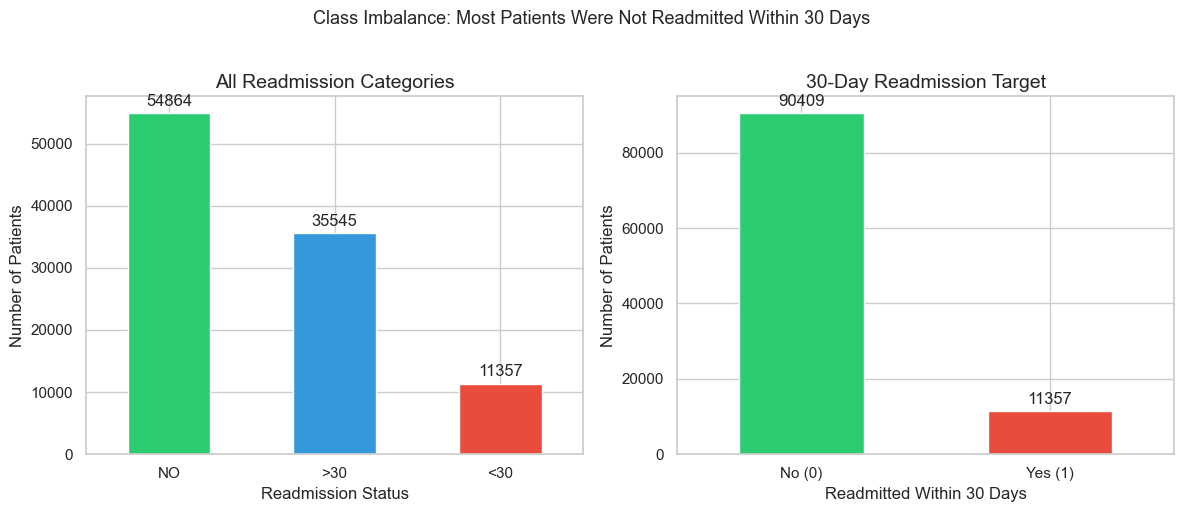

Chart saved to reports/


In [5]:
# Cell 4: Visualize class imbalance

from pathlib import Path

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original readmission categories
readmission_counts = df["readmitted"].value_counts().reindex(["NO", ">30", "<30"])

readmission_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["#2ecc71", "#3498db", "#e74c3c"],
    edgecolor="white",
)

axes[0].set_title("All Readmission Categories")
axes[0].set_xlabel("Readmission Status")
axes[0].set_ylabel("Number of Patients")
axes[0].tick_params(axis="x", rotation=0)
axes[0].bar_label(axes[0].containers[0], fmt="%.0f", padding=3)

# Right: binary target
target_counts = df["readmitted_30d"].value_counts().reindex([0, 1])

target_counts.plot(
    kind="bar",
    ax=axes[1],
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white",
)

axes[1].set_title("30-Day Readmission Target")
axes[1].set_xlabel("Readmitted Within 30 Days")
axes[1].set_ylabel("Number of Patients")
axes[1].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
axes[1].bar_label(axes[1].containers[0], fmt="%.0f", padding=3)

plt.suptitle(
    "Class Imbalance: Most Patients Were Not Readmitted Within 30 Days",
    fontsize=13,
    y=1.02,
)

plt.tight_layout()
plt.savefig(reports_dir / "01_class_imbalance.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Chart saved to {reports_dir}/")

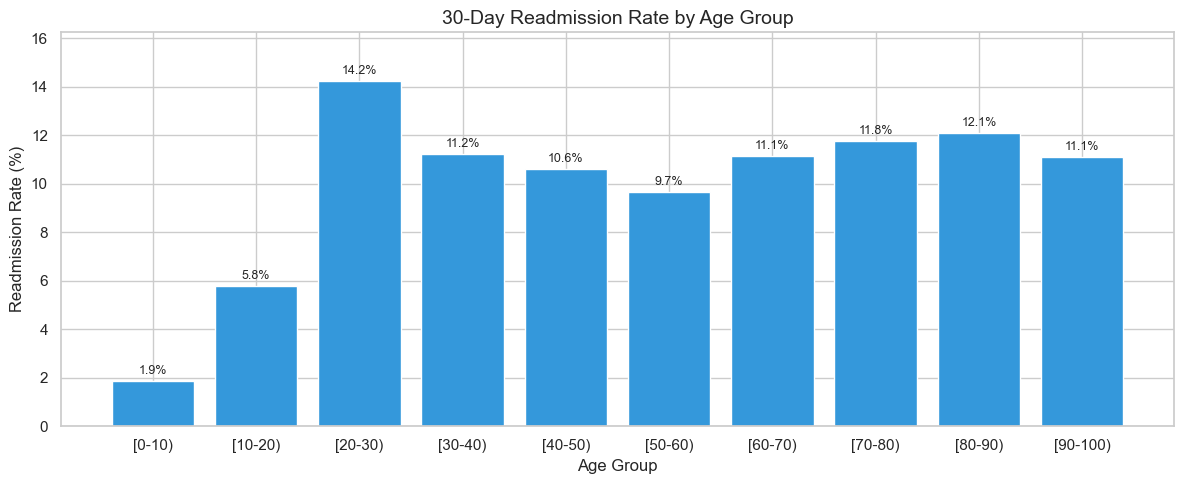

In [6]:
# Cell 5: Age vs. readmission

from pathlib import Path

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)

age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_readmit = (
    df.groupby("age")["readmitted_30d"]
    .mean()
    .mul(100)
    .reindex(age_order)
)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    age_readmit.index,
    age_readmit.values,
    color="#3498db",
    edgecolor="white",
)

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.ylim(0, age_readmit.max() + 2)

plt.bar_label(bars, labels=[f"{val:.1f}%" for val in age_readmit], padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(reports_dir / "02_age_readmission.png", bbox_inches="tight", dpi=150)
plt.show()

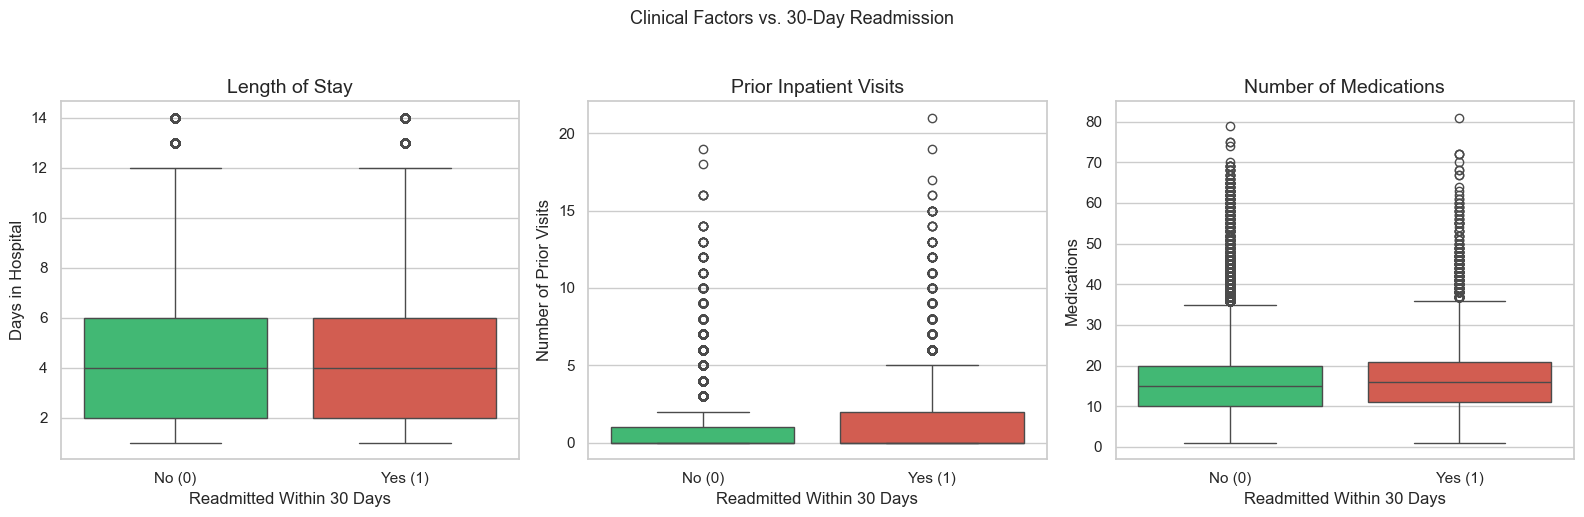

In [7]:
# Cell 6: Clinical utilization vs. readmission

from pathlib import Path

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)

clinical_features = {
    "time_in_hospital": ("Length of Stay", "Days in Hospital"),
    "number_inpatient": ("Prior Inpatient Visits", "Number of Prior Visits"),
    "num_medications": ("Number of Medications", "Medications"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (feature, (title, ylabel)) in zip(axes, clinical_features.items()):
    sns.boxplot(
        data=df,
        x="readmitted_30d",
        y=feature,
        ax=ax,
        palette=["#2ecc71", "#e74c3c"],
    )

    ax.set_title(title)
    ax.set_xlabel("Readmitted Within 30 Days")
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(["No (0)", "Yes (1)"])

plt.suptitle("Clinical Factors vs. 30-Day Readmission", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(reports_dir / "03_clinical_factors.png", bbox_inches="tight", dpi=150)
plt.show()

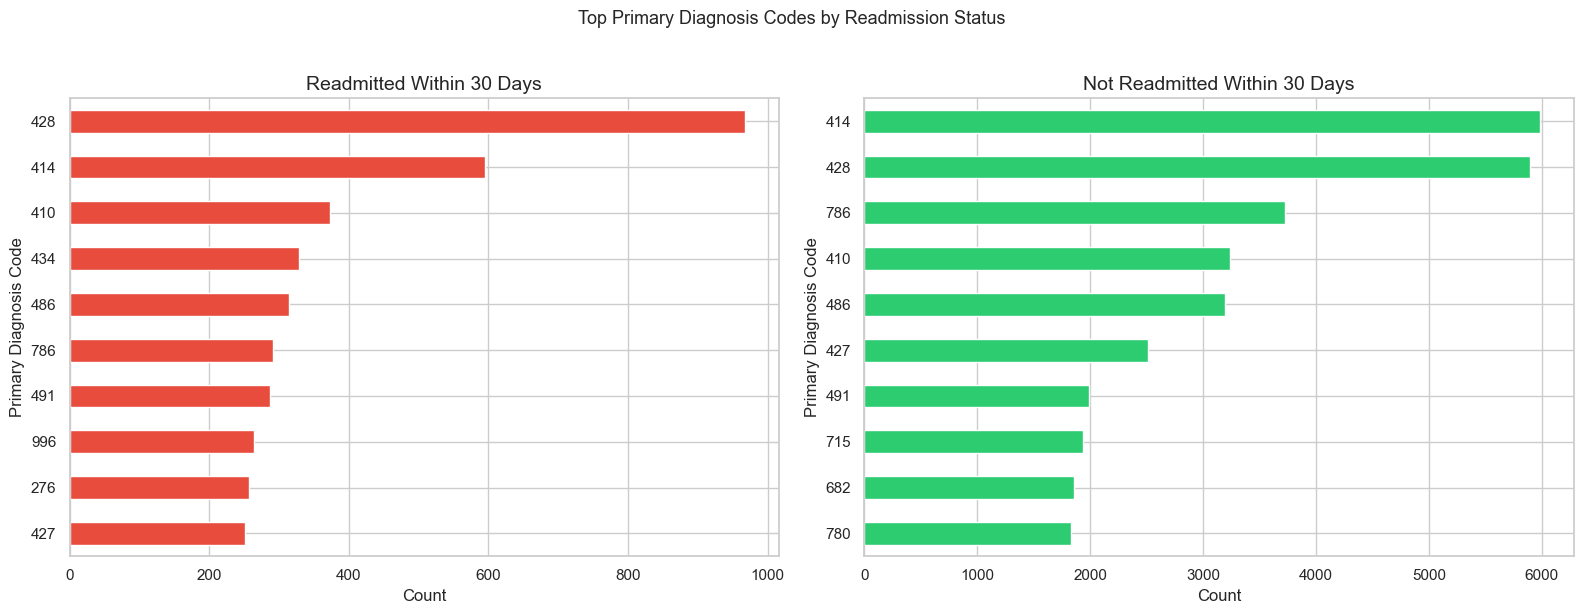

In [8]:
# Cell 7: Most common primary diagnoses by readmission status

from pathlib import Path

reports_dir = Path("reports")
reports_dir.mkdir(exist_ok=True)

readmitted_pts = df[df["readmitted_30d"] == 1]
not_readmitted = df[df["readmitted_30d"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

groups = {
    "Readmitted Within 30 Days": (readmitted_pts, "#e74c3c"),
    "Not Readmitted Within 30 Days": (not_readmitted, "#2ecc71"),
}

for ax, (title, (group_df, color)) in zip(axes, groups.items()):
    top_diagnoses = group_df["diag_1"].value_counts().head(10)

    top_diagnoses.plot(
        kind="barh",
        ax=ax,
        color=color,
        edgecolor="white",
    )

    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("Primary Diagnosis Code")
    ax.invert_yaxis()

plt.suptitle("Top Primary Diagnosis Codes by Readmission Status", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(reports_dir / "04_top_diagnoses.png", bbox_inches="tight", dpi=150)
plt.show()

In [9]:
# Cell 8: Key findings summary

print("=" * 55)
print("PHASE 2 KEY FINDINGS")
print("=" * 55)

readmission_rate = df["readmitted_30d"].mean() * 100

avg_los_yes = df.loc[df["readmitted_30d"] == 1, "time_in_hospital"].mean()
avg_los_no = df.loc[df["readmitted_30d"] == 0, "time_in_hospital"].mean()

avg_inp_yes = df.loc[df["readmitted_30d"] == 1, "number_inpatient"].mean()
avg_inp_no = df.loc[df["readmitted_30d"] == 0, "number_inpatient"].mean()

avg_med_yes = df.loc[df["readmitted_30d"] == 1, "num_medications"].mean()
avg_med_no = df.loc[df["readmitted_30d"] == 0, "num_medications"].mean()

print("\n1. CLASS IMBALANCE")
print(f"   {readmission_rate:.1f}% of patients were readmitted within 30 days")
print("   This imbalance should be handled during modeling.")

print("\n2. LENGTH OF STAY")
print(f"   Readmitted patients avg stay:     {avg_los_yes:.1f} days")
print(f"   Non-readmitted patients avg stay: {avg_los_no:.1f} days")

print("\n3. PRIOR INPATIENT VISITS")
print(f"   Readmitted patients avg prior visits:     {avg_inp_yes:.2f}")
print(f"   Non-readmitted patients avg prior visits: {avg_inp_no:.2f}")

print("\n4. MEDICATIONS")
print(f"   Readmitted patients avg medications:     {avg_med_yes:.1f}")
print(f"   Non-readmitted patients avg medications: {avg_med_no:.1f}")

missing_plan = {
    "weight": "drop this column",
    "medical_specialty": "group missing values or simplify categories",
    "payer_code": "drop this column",
}

print("\n5. MISSING DATA TO ADDRESS IN PHASE 3")
for col, action in missing_plan.items():
    missing_pct = (df[col] == "?").mean() * 100
    print(f"   {col}: {missing_pct:.1f}% missing -> {action}")

PHASE 2 KEY FINDINGS

1. CLASS IMBALANCE
   11.2% of patients were readmitted within 30 days
   This imbalance should be handled during modeling.

2. LENGTH OF STAY
   Readmitted patients avg stay:     4.8 days
   Non-readmitted patients avg stay: 4.3 days

3. PRIOR INPATIENT VISITS
   Readmitted patients avg prior visits:     1.22
   Non-readmitted patients avg prior visits: 0.56

4. MEDICATIONS
   Readmitted patients avg medications:     16.9
   Non-readmitted patients avg medications: 15.9

5. MISSING DATA TO ADDRESS IN PHASE 3
   weight: 96.9% missing -> drop this column
   medical_specialty: 49.1% missing -> group missing values or simplify categories
   payer_code: 39.6% missing -> drop this column
